In [1]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(parallel)
library(ggplot2)
library(readr)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [2]:
load("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_prediction_spearman_select.Rdata")

In [4]:
# metabolite <- read_tsv("/vol/projects/CIIM/cohorts_old/500FG/metabolic/500FG raw metabolite_fromJianbo.tsv")
# head(metabolite)
# dim(metabolite)
# metabolite_num <- metabolite[,c(22:479)]
# metabolite_num <- as.data.frame(metabolite_num)
# rownames(metabolite_num) <- metabolite$ metabolite_identification
# head(metabolite_num)
# dim(metabolite_num)
# any(is.na(metabolite_num))
# # 转置 cytokine_filter 数据框
# metabolite_trans <- as.data.frame(t(metabolite_num))
# colnames(metabolite_trans) <- rownames(metabolite_num)
# rownames(metabolite_trans) <- colnames(metabolite_num)
# dim(metabolite_trans)
# head(metabolite_trans)
# saveRDS(metabolite_trans, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/metabolite_trans.rds")

Rows: 1596 Columns: 479
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (5): database_identifier, chemical_formula, smiles, inchi, metabolite_...
dbl (460): mass_to_charge, reliability, HV001, HV002, HV003, HV004, HV005, H...
lgl  (14): fragmentation, modifications, charge, retention_time, taxid, spec...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


database_identifier,chemical_formula,smiles,inchi,metabolite_identification,mass_to_charge,fragmentation,modifications,charge,retention_time,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CHEBI:10022,C15H20O6,[H][C@@]12O[C@]3([H])C=C(C)C(=O)[C@@H](O)[C@]3(CO)[C@@](C)(C[C@H]1O)[C@]21CO1,"InChI=1S/C15H20O6/c1-7-3-9-14(5-16,11(19)10(7)18)13(2)4-8(17)12(21-9)15(13)6-20-15/h3,8-9,11-12,16-17,19H,4-6H2,1-2H3/t8-,9-,11-,12-,13-,14-,15+/m1/s1",Deoxynivalenol,295.1191,NA,NA,NA,NA,⋯,18349.0,44987.5,22414.5,19734.0,21075.5,16550.0,20302.0,12916.5,13331.0,36608.0
CHEBI:10075,C16H16O3,COc1cc(O)ccc1C\C=C\c1ccc(O)cc1,"InChI=1S/C16H16O3/c1-19-16-11-15(18)10-7-13(16)4-2-3-12-5-8-14(17)9-6-12/h2-3,5-11,17-18H,4H2,1H3/b3-2+",Xenognosin A,255.1038,NA,NA,NA,NA,⋯,17442.5,23112.5,18458.0,15341.0,17501.0,12886.5,13475.0,20116.5,18011.5,18617.5
CHEBI:10137,C17H26O3,CCCCCCCC(=O)CCc1ccc(O)c(OC)c1,"InChI=1S/C17H26O3/c1-3-4-5-6-7-8-15(18)11-9-14-10-12-16(19)17(13-14)20-2/h10,12-13,19H,3-9,11H2,1-2H3",1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,277.1809,NA,NA,NA,NA,⋯,410828.5,424573.0,784687.0,294914.5,864931.0,356691.0,424070.5,382228.5,465130.0,370595.5
CHEBI:10366,C7H14O4,[H]C([H])(C=O)[C@]([H])(OC)[C@]([H])(O)[C@@]([H])(C)O,"InChI=1S/C7H14O4/c1-5(9)7(10)6(11-2)3-4-8/h4-7,9-10H,3H2,1-2H3/t5-,6+,7-/m1/s1",Cymarose,161.0819,NA,NA,NA,NA,⋯,10493.0,10690.0,10907.5,9893.0,11671.5,10216.5,11271.0,10342.5,10849.5,9935.5
CHEBI:10368,C7H14O5,[H][C@](C)(O)[C@]([H])(O)[C@]([H])(OC)[C@@]([H])(O)C=O,"InChI=1S/C7H14O5/c1-4(9)6(11)7(12-2)5(10)3-8/h3-7,9-11H,1-2H3/t4-,5+,6+,7-/m1/s1",Digitalose,177.0772,NA,NA,NA,NA,⋯,17688.0,14362.5,16077.5,14465.5,19710.0,14843.5,14253.5,15513.0,13962.5,13581.0
CHEBI:10432,C10H8O,Oc1ccc2ccccc2c1,"InChI=1S/C10H8O/c11-10-6-5-8-3-1-2-4-9(8)7-10/h1-7,11H",2-Naphthol,143.0493,NA,NA,NA,NA,⋯,24687.0,20415.5,23917.5,19506.5,20907.0,18360.0,18922.0,19580.0,17712.0,16752.5


[1] 1596  479

,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV011,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Deoxynivalenol,20325.5,20604.5,30331.0,14997.0,13991.0,15048.5,17086.0,19065.5,36626.5,20855.0,⋯,18349.0,44987.5,22414.5,19734.0,21075.5,16550.0,20302.0,12916.5,13331.0,36608.0
Xenognosin A,16030.5,18831.5,24791.5,17869.5,15543.5,17714.5,14684.5,16868.0,16668.0,16151.0,⋯,17442.5,23112.5,18458.0,15341.0,17501.0,12886.5,13475.0,20116.5,18011.5,18617.5
1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,388846.0,324465.0,331666.5,374568.5,318622.0,387658.5,434873.0,400345.5,276148.0,258801.0,⋯,410828.5,424573.0,784687.0,294914.5,864931.0,356691.0,424070.5,382228.5,465130.0,370595.5
Cymarose,10987.5,9602.0,9588.0,9072.5,8679.5,9029.5,10611.0,9393.0,9817.0,9269.5,⋯,10493.0,10690.0,10907.5,9893.0,11671.5,10216.5,11271.0,10342.5,10849.5,9935.5
Digitalose,14547.0,12737.0,13865.5,13150.0,13636.5,13891.5,15179.5,12754.5,13344.0,14238.0,⋯,17688.0,14362.5,16077.5,14465.5,19710.0,14843.5,14253.5,15513.0,13962.5,13581.0
2-Naphthol,21882.5,19354.5,17533.0,20510.5,18029.0,21299.0,21016.5,21188.5,18381.5,19498.5,⋯,24687.0,20415.5,23917.5,19506.5,20907.0,18360.0,18922.0,19580.0,17712.0,16752.5


[1] 1596  458

[1] FALSE

[1]  458 1596

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,Dihydroisomorphine-3-glucuronide,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,20325.5,16030.5,388846.0,10987.5,14547.0,21882.5,14201.0,14650.5,8620.5,11428,⋯,13142.5,14167.0,9401.5,17702.5,17702.5,10169.5,17017.0,19663.0,30233.5,126298.0
HV002,20604.5,18831.5,324465.0,9602.0,12737.0,19354.5,20310.0,14790.0,8081.0,14077,⋯,11661.0,34008.5,9580.5,16853.5,16853.5,13238.5,18201.0,20731.0,35445.0,60949.5
HV003,30331.0,24791.5,331666.5,9588.0,13865.5,17533.0,19598.0,14537.0,7405.0,11285,⋯,20263.0,14685.0,23445.5,20627.5,20627.5,15032.5,15631.5,23595.0,36253.0,48469.0
HV004,14997.0,17869.5,374568.5,9072.5,13150.0,20510.5,18216.5,16288.0,7810.0,12780,⋯,15027.5,12052.0,9388.5,16298.0,16298.0,12874.0,18982.0,21619.5,34825.5,63373.0
HV005,13991.0,15543.5,318622.0,8679.5,13636.5,18029.0,19823.5,14830.5,8571.0,15183,⋯,36945.0,13568.5,12124.0,35662.5,35662.5,16768.0,16786.5,19816.5,35610.5,42202.5
HV006,15048.5,17714.5,387658.5,9029.5,13891.5,21299.0,20080.0,15122.5,7532.0,11903,⋯,29487.0,13197.5,10096.5,16939.0,16939.0,13932.5,15564.0,18517.0,33008.5,272100.0


In [7]:
metabolite  <- read.csv("/vol/projects/yzhang/500FG_aging/input/metabolite/metabolite_rank_normalized.csv",row.names=1,check.names=FALSE) 
head(metabolite)
dim(metabolite)

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,Dihydroisomorphine-3-glucuronide,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,-0.09042738,-0.6405208,-0.4988232,0.8581137,0.03010598,1.09634971,-2.7188860,-0.42572852,0.69524853,-0.6007073,⋯,-1.0289707,-0.4078196,-0.834622782,0.15107993,0.15107993,-2.3329522,0.4437750,-0.09042738,-0.59416502,0.4619673
HV002,-0.01915663,0.4680652,-1.2022733,-0.4558865,-1.19107421,0.05749803,0.8039993,-0.27431469,0.06298097,0.8660497,⋯,-1.3369998,2.0844649,-0.613869888,-0.10142389,-0.10142389,-0.1069267,1.2022733,0.35484272,0.56182419,-0.9572760
HV003,1.28529288,1.6752435,-1.1477018,-0.4741805,-0.44377503,-0.95727604,0.4317283,-0.53636972,-0.74490049,-0.7163113,⋯,0.3143238,-0.1732621,3.064079868,0.81921500,0.81921500,0.6405208,-0.4498225,1.40713067,0.76674786,-1.5187678
HV004,-1.57299263,0.1843845,-0.6744898,-1.0289707,-1.01055999,0.58115592,-0.3085788,1.00148190,-0.29140400,0.2403697,⋯,-0.5618242,-1.6752435,-0.858113680,-0.25730513,-0.25730513,-0.3374100,1.7461435,0.68137666,0.41377444,-0.8901927
HV005,-1.99675754,-0.8983563,-1.3107083,-1.4372217,-0.55542701,-0.62049112,0.5876480,-0.23474008,0.65401765,1.3782625,⋯,1.5729926,-0.6952485,1.697937012,2.71888598,2.71888598,1.0477369,0.3028440,-0.01915663,0.58764804,-1.8270943
HV006,-1.55440712,0.1179421,-0.5050309,-1.0864214,-0.40781961,0.88208793,0.6952485,0.03558193,-0.60727546,-0.3085788,⋯,1.1691131,-0.8502313,-0.002736497,-0.05201683,-0.05201683,0.2516520,-0.5050309,-0.63381606,0.05749803,1.3925515


[1]  458 1596

In [8]:
##fliter common sample in all layer
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples.rds")  
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/multi-omics_common_sample_without_microbiome.rds") 
common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples_nogenptype.rds")
metabolite_trans <- metabolite[common_samples, , drop = FALSE]
dim(metabolite_trans)
any(is.na(metabolite_trans))

[1]  186 1596

[1] FALSE

In [9]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(metabolite_trans), basicPhenos$ID_500fg) 
length(idx) #458samples
metabolite_filter = metabolite_trans[which(rownames(metabolite_trans) %in% idx),]
head(metabolite_filter)  #458samples,1596 metabolite
dim(metabolite_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(metabolite_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(metabolite_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(metabolite_trans))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
#write.csv(metabolite_filter, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_metabolite_filter_age.csv")
#write.csv(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_basicPhenos_filter_match_metabolite_age.csv")
#save(metabolite_filter, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_metabolite_filter_age.RData")
#save(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_basicPhenos_filter_match_metabolite_age.RData")

[1] 186

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,Dihydroisomorphine-3-glucuronide,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,0.73769684,-0.1014239,-2.13512144,-0.2800020,-0.8820879,-1.21362533,1.67524352,0.3316220,-0.7667479,-0.8740407,⋯,0.8346228,-1.3642494,-0.08493331,1.1268041,1.1268041,-0.1344926,0.2800020,0.6540176,-1.10638723,0.6138699
HV028,0.71631134,-0.2066995,0.19552986,0.6540176,0.1455464,0.54905248,-1.04773694,-0.3490201,1.5729926,-1.0572598,⋯,-1.5016490,-0.3723840,0.39595295,-0.4437750,-0.4437750,3.0640799,1.0668796,0.5554270,0.79646090,0.1955299
HV029,-0.08493331,0.5811559,-0.83462278,0.4498225,-0.9924856,0.04105894,-0.03558193,-0.1400173,0.9924856,-1.1165375,⋯,1.8270943,1.4220152,1.43722165,0.2403697,0.2403697,-0.1955299,-0.9835689,0.5112581,0.33740998,0.3374100
HV030,-1.72154023,-0.2914040,-1.46867339,0.4680652,-0.1899543,0.29140400,0.38414179,-0.4926347,-0.1843845,-1.2022733,⋯,-0.2403697,-0.3028440,0.04653719,0.6608108,0.6608108,0.6540176,-0.8740407,0.8502313,0.06298097,-0.3490201
HV031,0.22911789,0.4498225,-0.09592419,-1.3782625,-0.2235029,0.17326210,1.42201521,-0.4864649,-0.5618242,1.2978958,⋯,-0.5682444,0.6608108,-0.64052082,1.7987869,1.7987869,1.5729926,-2.2568497,-0.7092555,0.38414179,-1.5363435
HV033,-1.40713067,-0.1677090,1.03830810,0.4197440,0.5811559,-0.36067741,0.50503092,0.8660497,-0.4137744,0.1677090,⋯,-0.6138699,-1.7987869,-0.62713967,0.7964609,0.7964609,0.5300607,0.1621610,0.9747298,1.65338135,0.5618242


[1]  186 1596

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
2,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
3,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
4,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
5,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1
6,207,HV054,male,18,182,64,19.32134,Married,University student,European,Never,No,No,30,9,270,2013,Group 1


[1] 186  18

[1] 1

[1] 186

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
39,196,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013,Group 2
164,203,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013,Group 5
127,180,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013,Group 4
145,197,HV030,female,25,161,57,21.98989,Single living alone,Hogeschool opleiding (HBO),European,Never,No,No,3,10,273,2013,Group 4
64,181,HV031,female,21,180,66,20.37037,Married,University student,European,Once a month,Yes,No,7,10,277,2013,Group 2
59,162,HV033,female,21,165,63,23.14050,Married,University student,European,Rarely,No,No,14,10,284,2013,Group 2


[1] 186  18

In [10]:
metabolite_age <- cbind(metabolite_filter, Age = basicPhenos_filter_match$Age)
head(metabolite_age)
dim(metabolite_age)

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV022,0.73769684,-0.1014239,-2.13512144,-0.2800020,-0.8820879,-1.21362533,1.67524352,0.3316220,-0.7667479,-0.8740407,⋯,-1.3642494,-0.08493331,1.1268041,1.1268041,-0.1344926,0.2800020,0.6540176,-1.10638723,0.6138699,20
HV028,0.71631134,-0.2066995,0.19552986,0.6540176,0.1455464,0.54905248,-1.04773694,-0.3490201,1.5729926,-1.0572598,⋯,-0.3723840,0.39595295,-0.4437750,-0.4437750,3.0640799,1.0668796,0.5554270,0.79646090,0.1955299,29
HV029,-0.08493331,0.5811559,-0.83462278,0.4498225,-0.9924856,0.04105894,-0.03558193,-0.1400173,0.9924856,-1.1165375,⋯,1.4220152,1.43722165,0.2403697,0.2403697,-0.1955299,-0.9835689,0.5112581,0.33740998,0.3374100,24
HV030,-1.72154023,-0.2914040,-1.46867339,0.4680652,-0.1899543,0.29140400,0.38414179,-0.4926347,-0.1843845,-1.2022733,⋯,-0.3028440,0.04653719,0.6608108,0.6608108,0.6540176,-0.8740407,0.8502313,0.06298097,-0.3490201,25
HV031,0.22911789,0.4498225,-0.09592419,-1.3782625,-0.2235029,0.17326210,1.42201521,-0.4864649,-0.5618242,1.2978958,⋯,0.6608108,-0.64052082,1.7987869,1.7987869,1.5729926,-2.2568497,-0.7092555,0.38414179,-1.5363435,21
HV033,-1.40713067,-0.1677090,1.03830810,0.4197440,0.5811559,-0.36067741,0.50503092,0.8660497,-0.4137744,0.1677090,⋯,-1.7987869,-0.62713967,0.7964609,0.7964609,0.5300607,0.1621610,0.9747298,1.65338135,0.5618242,21


[1]  186 1597

In [11]:
basicPhenos_filter_match$Gender <- trimws(as.character(basicPhenos_filter_match$Gender))
basicPhenos_filter_match$Gender[basicPhenos_filter_match$Gender == ""] <- NA

id2gender <- setNames(basicPhenos_filter_match$Gender, basicPhenos_filter_match$ID_500fg)
metabolite_age$Gender <- id2gender[rownames(metabolite_age)]

head(metabolite_age)
dim(metabolite_age)

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,"(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid,Age,Gender
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
HV022,0.73769684,-0.1014239,-2.13512144,-0.2800020,-0.8820879,-1.21362533,1.67524352,0.3316220,-0.7667479,-0.8740407,⋯,-0.08493331,1.1268041,1.1268041,-0.1344926,0.2800020,0.6540176,-1.10638723,0.6138699,20,female
HV028,0.71631134,-0.2066995,0.19552986,0.6540176,0.1455464,0.54905248,-1.04773694,-0.3490201,1.5729926,-1.0572598,⋯,0.39595295,-0.4437750,-0.4437750,3.0640799,1.0668796,0.5554270,0.79646090,0.1955299,29,female
HV029,-0.08493331,0.5811559,-0.83462278,0.4498225,-0.9924856,0.04105894,-0.03558193,-0.1400173,0.9924856,-1.1165375,⋯,1.43722165,0.2403697,0.2403697,-0.1955299,-0.9835689,0.5112581,0.33740998,0.3374100,24,male
HV030,-1.72154023,-0.2914040,-1.46867339,0.4680652,-0.1899543,0.29140400,0.38414179,-0.4926347,-0.1843845,-1.2022733,⋯,0.04653719,0.6608108,0.6608108,0.6540176,-0.8740407,0.8502313,0.06298097,-0.3490201,25,female
HV031,0.22911789,0.4498225,-0.09592419,-1.3782625,-0.2235029,0.17326210,1.42201521,-0.4864649,-0.5618242,1.2978958,⋯,-0.64052082,1.7987869,1.7987869,1.5729926,-2.2568497,-0.7092555,0.38414179,-1.5363435,21,female
HV033,-1.40713067,-0.1677090,1.03830810,0.4197440,0.5811559,-0.36067741,0.50503092,0.8660497,-0.4137744,0.1677090,⋯,-0.62713967,0.7964609,0.7964609,0.5300607,0.1621610,0.9747298,1.65338135,0.5618242,21,female


[1]  186 1598

In [8]:
# Create directory to store results
dir.create("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/metabolite_spearman_preparation", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Initialize list to store all iterations results
all_results <- list()

# Function to train and evaluate
train_and_evaluate <- function(data, seed, iteration) {
  #set.seed(seed)
  # Get the split indices from all_iterations_common_results1.rds
   iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]  # Extract the indices from the matrix
  # Split data
 # split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  print(dim(training))  # Should have ~70% of the original rows
  # Should be 5000 (excluding Age) 
 
  # Get feature names
  feature_names <- setdiff(names(training), "Age")  
  feature_batches <- split(feature_names, ceiling(seq_along(feature_names) / 500))  
    print(length(feature_names))

  RNGkind("L'Ecuyer-CMRG")
  set.seed(123)
    
  # Compute Spearman correlation
  spearman_results <- lapply(feature_batches, function(batch) {
    sapply(batch, function(feature) {
      if (!feature %in% names(training)) return(c(cor = NA, pvalue = NA))
      if (var(training[[feature]], na.rm = TRUE) == 0) return(c(cor = NA, pvalue = NA))
      
      test <- tryCatch(
        cor.test(training[[feature]], training$Age, method = "spearman"),
        error = function(e) return(NULL)
      )

      if (is.null(test)) return(c(cor = NA, pvalue = NA))
      return(c(cor = test$estimate, pvalue = test$p.value))
    }, simplify = FALSE)
  })
       if (length(spearman_results) == 0 || is.null(spearman_results[[1]])) {
    stop("Error: spearman_results is empty or NULL. Check execution.")
  }
  print(length(spearman_results))
  # Extract p-values
  spearman_pvalues <- unlist(lapply(spearman_results, function(batch) {
    sapply(batch, function(x) if (!is.null(x)) x["pvalue"] else NA)
  }))
   print(summary(spearman_pvalues))  

  # Get corresponding feature names
  #feature_names <- names(spearman_pvalues)
 # names(spearman_pvalues) <- feature_names
   feature_names <- unlist(lapply(spearman_results, names))
  print(length(spearman_pvalues))  # p-value 总数
  print(head(spearman_pvalues))    # 预览前几个 p-values
  print(names(spearman_pvalues)[1:10])       
 
 
if (length(feature_names) != length(spearman_pvalues)) {
    stop("Error: Mismatch between feature names and spearman_pvalues length.")
  }
   names(spearman_pvalues) <- feature_names
  
    # Filter features with p-value < 0.05
   selected_features <- names(spearman_pvalues[spearman_pvalues < 0.05])        
  
  # Store results in list
  results <- list(
    split_indices = split_indices,
    selected_features = selected_features,
    spearman_pvalues = spearman_pvalues[selected_features] # 只存筛选出的 p-value
  )

  rm(training, validation, feature_batches, spearman_results, spearman_pvalues, feature_names)
  gc()  

  return(results)
}

           
# Run 100 iterations
#for (i in 1:2) {
#  cat("Running iteration", i, "\n")
#  train_and_evaluate(Mvalue_age, seed = 123 + i, iteration = i)
#}
#iteration_results <- mclapply(1:100, function(i) {
iteration_results <- lapply(1:100, function(i) {
  train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i)
})

# 合并结果
for (i in 1:100) {
  all_results[[i]] <- iteration_results[[i]]
}

           # Save all results in a single RDS file
if (length(all_results) > 0) {
  saveRDS(all_results, "/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/metabolite_spearman_preparation/metabolite_iterations_results_quoteID.rds")
} else {
  cat("Error: all_results is empty, nothing to save.\n")
}

[1]  132 1597
[1] 1596


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 4
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000016 0.0944667 0.3286003 0.3835856 0.6382855 0.9983319 
[1] 1596
                          1.Deoxynivalenol.pvalue 
                                        0.8632956 
                            1.Xenognosin A.pvalue 
                                        0.0154743 
1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue 
                                        0.4577931 
                                1.Cymarose.pvalue 
                                        0.3379021 
                              1.Digitalose.pvalue 
                                        0.3717904 
                              1.2-Naphthol.pvalue 
                                        0.3894314 
 [1] "1.Deoxynivalenol.pvalue"                                              
 [2] "1.Xenognosin A.pvalue"                                                
 [3] "1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue"                    
 [4] "1.Cymarose.pva

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 4
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000001 0.0784267 0.3045781 0.3728954 0.6556349 0.9978565 
[1] 1596
                          1.Deoxynivalenol.pvalue 
                                       0.66497495 
                            1.Xenognosin A.pvalue 
                                       0.07126003 
1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue 
                                       0.24637325 
                                1.Cymarose.pvalue 
                                       0.61729530 
                              1.Digitalose.pvalue 
                                       0.41829324 
                              1.2-Naphthol.pvalue 
                                       0.26602004 
 [1] "1.Deoxynivalenol.pvalue"                                              
 [2] "1.Xenognosin A.pvalue"                                                
 [3] "1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue"                    
 [4] "1.Cymarose.pva

...

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 4
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000001 0.1154777 0.3641969 0.4034817 0.6523874 0.9988444 
[1] 1596
                          1.Deoxynivalenol.pvalue 
                                        0.2112273 
                            1.Xenognosin A.pvalue 
                                        0.1215204 
1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue 
                                        0.5729550 
                                1.Cymarose.pvalue 
                                        0.8320354 
                              1.Digitalose.pvalue 
                                        0.6502741 
                              1.2-Naphthol.pvalue 
                                        0.1811227 
 [1] "1.Deoxynivalenol.pvalue"                                              
 [2] "1.Xenognosin A.pvalue"                                                
 [3] "1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue"                    
 [4] "1.Cymarose.pva

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 4
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.04703 0.23365 0.32294 0.55180 0.99821 
[1] 1596
                          1.Deoxynivalenol.pvalue 
                                       0.08950280 
                            1.Xenognosin A.pvalue 
                                       0.01480571 
1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue 
                                       0.95291203 
                                1.Cymarose.pvalue 
                                       0.25738034 
                              1.Digitalose.pvalue 
                                       0.10022118 
                              1.2-Naphthol.pvalue 
                                       0.43899596 
 [1] "1.Deoxynivalenol.pvalue"                                              
 [2] "1.Xenognosin A.pvalue"                                                
 [3] "1.1-(4-Hydroxy-3-methoxyphenyl)-3-decanone.pvalue"                    
 [4] "1.Cymarose.pvalue"                    

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

In [9]:
str(all_results)

List of 100
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 3 4 5 6 7 8 9 10 12 ...
  ..$ selected_features: chr [1:265] "Xenognosin A" "Octadecanedioic acid" "Ferulic acid 4-sulfate" "Stearoylglycine" ...
  ..$ spearman_pvalues : Named num [1:265] 0.01547 0.01778 0.00095 0.0311 0.03672 ...
  .. ..- attr(*, "names")= chr [1:265] "Xenognosin A" "Octadecanedioic acid" "Ferulic acid 4-sulfate" "Stearoylglycine" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 2 4 6 7 8 10 11 12 13 14 ...
  ..$ selected_features: chr [1:309] "N,N'-Diacetylchitobiosyldiphosphodolichol" "Ferulic acid 4-sulfate" "Tetraphyllin B" "13'-Carboxy-gamma-tocotrienol" ...
  ..$ spearman_pvalues : Named num [1:309] 3.28e-02 1.97e-05 3.22e-02 1.21e-02 7.92e-03 ...
  .. ..- attr(*, "names")= chr [1:309] "N,N'-Diacetylchitobiosyldiphosphodolichol" "Ferulic acid 4-sulfate" "Tetraphyllin B" "13'-Carboxy-gamma-tocotrienol" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 2 3 4 7 8 10 11 12 13 ...
  ..$ se

In [13]:
###save each model iteration to use in the mutli-omics data
# Create a folder to save data for each experiment
dir.create("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/gender/metabolite_spearman_pvalue_common_select_prediction_results_quoteID_gender", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Custom function to train and evaluate, saving split indices and selected features
train_and_evaluate <- function(data, seed, iteration, pvalue_threshold) {
  # Set RNG kind and seed at the start, exactly as in code 2
 # RNGkind("L'Ecuyer-CMRG")
 # set.seed(seed)
  
  # Data splitting
  #split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)
 # Gender cleanup (one missing value as blank string)
  if (!"Gender" %in% names(data)) {
    stop("Gender column not found in input data.")
  }
  data$Gender <- trimws(as.character(data$Gender))
  data$Gender[data$Gender == ""] <- NA
    
     # Get the split indices from all_iterations_common_results1.rds
   iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]  # Extract the indices from the matrix
    
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  
 # Get the corresponding iteration results from both spearman results
  iteration_result <- all_results[[iteration]]

# Get p-values and features from the iteration result
all_pvalues <- iteration_result$spearman_pvalues
all_features <- iteration_result$selected_features
  
  # Ensure we're using the same split indices as in the spearman results
  if (!identical(split_indices, iteration_result$split_indices)) {
  warning("Split indices mismatch. Using original split indices from results.")
  split_indices <- iteration_result$split_indices
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
}

# Filter features based on p-value threshold
selected_features <- all_features[all_pvalues < pvalue_threshold]

     # Force Gender as a fixed feature
selected_features <- unique(c(selected_features, "Gender"))

  
  # Ensure we have selected features
  if (length(selected_features) == 0) {
    stop(paste("No features selected after filtering by p-value threshold", pvalue_threshold, "in iteration", iteration))
  }
  
  # Save split indices and selected features
  saveRDS(list(split_indices = split_indices, selected_features = selected_features),
          file = paste0("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/gender/metabolite_spearman_pvalue_common_select_prediction_results_quoteID_gender/iteration_", iteration, "_info.rds"))
  
  # Subset data to selected features
  training_selected <- training[, c(selected_features, "Age"), drop = FALSE]
  validation_selected <- validation[, c(selected_features, "Age"), drop = FALSE]
  # Drop rows with missing Gender after split, then encode Gender as numeric
  training_selected <- training_selected[!is.na(training_selected$Gender), , drop = FALSE]
  validation_selected <- validation_selected[!is.na(validation_selected$Gender), , drop = FALSE]
  gender_levels <- sort(unique(na.omit(data$Gender)))
  training_selected$Gender <- as.numeric(factor(training_selected$Gender, levels = gender_levels))
  validation_selected$Gender <- as.numeric(factor(validation_selected$Gender, levels = gender_levels))
   
  rm(training)
  rm(validation)
  gc()

  # Model training using glmnet
  #netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
    netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5)
  
  netFit <- train(Age ~ ., data = training_selected, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions
  train_predictions <- predict(netFit, newdata = training_selected)
  val_predictions <- predict(netFit, newdata = validation_selected)
  
  rm(netFit)
  gc()
    
 # Save predicted age for each sample
  pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training_selected),
      Age_true = training_selected$Age,
      Age_pred = as.numeric(train_predictions)
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation_selected),
      Age_true = validation_selected$Age,
      Age_pred = as.numeric(val_predictions)
    )
  ) 
      
      # Calculate performance metrics for the training set
train_rmse <- sqrt(mean((training_selected$Age - train_predictions)^2))  # RMSE
train_mse <- mean((training_selected$Age - train_predictions)^2)         # MSE
train_r_squared <- cor(training_selected$Age, train_predictions)^2       # R²

# Calculate performance metrics for the validation set
val_rmse <- sqrt(mean((validation_selected$Age - val_predictions)^2))    # RMSE
val_mse <- mean((validation_selected$Age - val_predictions)^2)           # MSE
val_r_squared <- cor(validation_selected$Age, val_predictions)^2         # R²
  
  rm(training_selected, validation_selected, train_predictions, val_predictions)
  gc()
      
      # Return results
return(list(
  train_RMSE = train_rmse,
  train_MSE = train_mse,               # Added MSE
  train_R2 = train_r_squared,
  val_RMSE = val_rmse,
  val_MSE = val_mse,                   # Added MSE
  val_R2 = val_r_squared,
  selected_features = selected_features,
  predictions = pred_df
))
}

In [14]:
set.seed(1)

batch_size <- 10  # 每个 batch 运行 10 次
num_batches <- 10  # 总 batch 数
results <- list() 

for (batch in 1:num_batches) {
    batch_results <- lapply(
    ((batch - 1) * batch_size + 1):(batch * batch_size), 
    function(i) {
       res <- train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, pvalue_threshold = 1)
      return(res)
    }
)
# Add batch results to results
  results <- c(results, batch_results)
  
  rm(batch_results)
  gc()
}

# Save all results in a single file
saveRDS(results, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/gender/metabolite_prediction_pvalue_common_select_results_spearman_quoteID_gender.rds")

# Save all predicted ages from 100 iterations in one file
all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/gender/metabolite_prediction_pvalue_common_select_age_predictions_quoteID_gender.csv", row.names = FALSE)


Warning message in train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(metabolite_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(metabolite_age, seed = 123

In [15]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)               

                       Metric        Mean         SD
1                  Train RMSE   6.4817554  1.4875700
2             Validation RMSE  10.1396383  1.7451436
3                   Train MSE  44.2038884 16.4614204
4              Validation MSE 105.8273351 36.4826185
5                    Train R²   0.7020620  0.1208313
6               Validation R²   0.2709686  0.1185594
7 Number of Selected Features 306.8900000 60.3633602


pdf 
  2

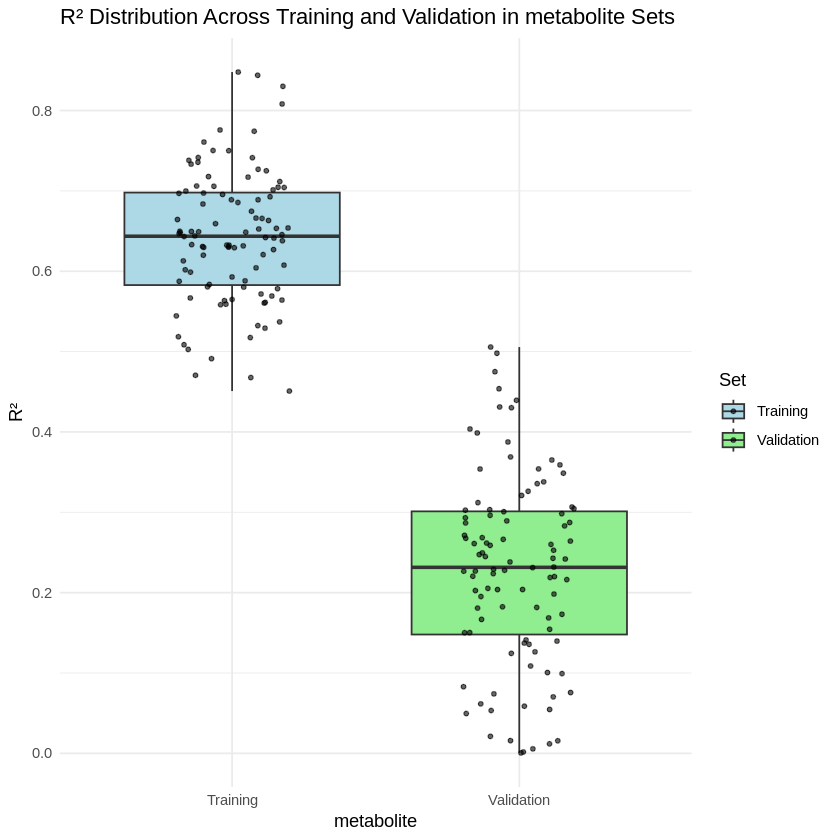

In [19]:
 plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)                                            
# Plot only R²
ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/12_prediction/metabolite_predicition_pvalue_common_select_spearman.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in metabolite Sets",
       x = "metabolite",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))
print(g)
# dev.off()    
# print(g)

In [16]:
save.image(file="/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_prediction_spearman_quoteID_gender.Rdata")